In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normalization(x):
 mu=np.mean(x,axis=0)
 stnd=np.std(x,axis=0)
 stnd=np.where(stnd==0,1e-10,stnd)
 return mu,stnd

In [3]:
def compute_cost(x,y,w,b,m,lambda_,):  
 cost = 0.0
 f_wb= np.dot(x,w.T)+b
 cost = (((f_wb-y.T)**2).sum())/2
 cost+=(lambda_*((w**2).sum()))/2
 cost = cost/m
 return cost

In [12]:
def gradient_descent(x,y,w,b,alpha,itrns,lambda_):
 m,n=x.shape
 J_history=[]
 for i in range(itrns):
   dJ_dw=np.zeros((n,))
   dJ_db=0.
   f=(np.dot(x,w.T)+b)
   e=f-y
   dJ_dw=np.dot(e,x)+lambda_*w
   dJ_db+=e.sum()
   dJ_dw=dJ_dw/m
   dJ_db=dJ_db/m
   w=w-alpha*dJ_dw
   b=b-alpha*dJ_db
   if i<10000:
     cost=compute_cost(x,y,w,b,m,lambda_)
     if i%(itrns/10)==0:
       print (f"Iteration {i}: Cost {cost}")
   J_history.append(cost)
 return w,b,cost,J_history

In [13]:
def R2Score(y,cost):
 rss=((y-np.mean(y))**2).sum()
 tss=cost*2*m
 r2s=1-tss/rss
 print(f"R2 Score: {r2s}")

Iteration 0: Cost 72933108664301.17
Iteration 1000: Cost 58754888529799.3
Iteration 2000: Cost 58754190869602.27
Iteration 3000: Cost 58753588500836.65
Iteration 4000: Cost 58753065990597.37
Iteration 5000: Cost 58752611514709.5
Iteration 6000: Cost 58752215013014.61
Iteration 7000: Cost 58751867926008.24
Iteration 8000: Cost 58751562970799.516
Iteration 9000: Cost 58751293950521.89
w,b found by gradient descent for training set:[  125.89191166  4823.5432217  -5937.81594911 59692.33717567
  -488.72992698]1964.3210736923509
R2 Score for training set : 
R2 Score: 0.17962619008799585


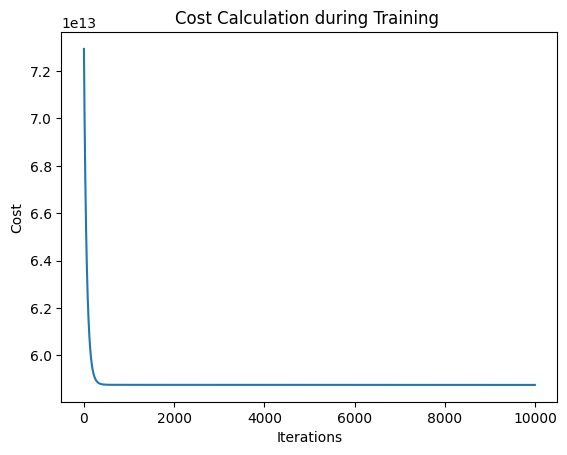

R2 Score for validation set : 
R2 Score: -1.7812292018772475
ID : 16588.0   cost: 669109.1012409138
ID : 17513.0   cost: 1988.8778248795802
ID : 14448.0   cost: 2544.5424477556376
ID : 13972.0   cost: 1079666.4783122262
ID : 18321.0   cost: 251817.37923710636
ID : 19593.0   cost: 23429.397630265936
ID : 16569.0   cost: 18507.80025465492
ID : 11736.0   cost: 83959.52492221665
ID : 18654.0   cost: 531434.7242444931
ID : 12539.0   cost: 66248.43273584792
ID : 19545.0   cost: 900449.4005405939
ID : 10113.0   cost: 1775863.047357321
ID : 19387.0   cost: 13691809.454915818
ID : 10985.0   cost: 108744.26039912735
ID : 18805.0   cost: 4017224.2694200557
ID : 12993.0   cost: 1311042.234850199
ID : 17187.0   cost: 3013483.3963133288
ID : 11290.0   cost: 2065.1325439652956
ID : 12106.0   cost: 78488.28454308951
ID : 11139.0   cost: 30338.447756035584
ID : 15128.0   cost: 292543.7674071276
ID : 12377.0   cost: 40901.17765802747
ID : 14751.0   cost: 25775.056873289017
ID : 16358.0   cost: 49080.294

In [16]:
 df=np.array(pd.read_csv("Polynomialdata_train.csv"))
 np.random.shuffle(df)
 x=df[:,1:]
 m,n = x.shape

 a=int(70/100*m)
 x_train=x[:a,:]
 mu,stnd=normalization(x_train)
 x_train=(x_train-mu)/stnd
 x_validate=x[a:,:]
 x_validate=(x_validate-mu)/stnd
 m,n=x_train.shape
 y=df[:,0]
 y_train=y[:a]
 y_validate=y[a:]
 w=np.random.randn(5,)
 b=np.random.rand()
 alpha=1e-06
 itrns=10000
 lambda_=100

 x_train=np.c_[x_train.sum(axis=1),(x_train.sum(axis=1))**2,(x_train.sum(axis=1))**3,(x_train.sum(axis=1))**4,(x_train.sum(axis=1))**5]
 w,b,cost,cost_history=gradient_descent(x_train,y_train,w,b,alpha,itrns,lambda_)
 print(f"w,b found by gradient descent for training set:{w}{b}")
 print(f"R2 Score for training set : ")
 R2Score(y_train,cost)

 plt.plot(cost_history)
 plt.xlabel('Iterations') 
 plt.ylabel('Cost' ) 
 plt.title('Cost Calculation during Training ' ) 
 plt.show()

 print(f"R2 Score for validation set : ")
 R2Score(y_validate,cost) 
 df1=np.array(pd.read_csv("Polynomialdata_test.csv"))
 x1=df1[:,1:]
 x1=(x1-mu)/stnd
 x1=np.c_[x1.sum(axis=1),(x1.sum(axis=1))**2,(x1.sum(axis=1))**3,(x1.sum(axis=1))**4,(x1.sum(axis=1))**5]
 y1=np.dot(x1,w.T)+b
 Id=df1[:,0]
 for i in range(len(Id)):
  print(f"ID : {Id[i]}   cost: {y1.T[i]}")

for d in range(1, degree + 1):
    for power_x in range(d + 1):
        for power_y in range(d - power_x + 1):
            power_z = d - power_x - power_y
            a = (x_train[:,0])**power_x
            b = (x_train[:,1])**power_y
            c = (x_train[:,2])**power_z
            prod=a*b*c
            count=0
            for i in range(len(x)-1):
             if(np.any(m==x)):
              count=count+1
            if count>0:
             continue
            x_train=np.c_[x_train,prod]